# **SEQUENCE MODEL FILTER COMPARISON: MISTRAL vs GPT2 vs MAMBA vs KALMAN**
## Run all code blocks sequentially

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from transformers import MistralModel, MistralConfig, GPT2Model, GPT2Config
from mamba_ssm import Mamba2 as Mamba
from filterpy.kalman import KalmanFilter


# Set random seeds for reproducibility
seed = 42
global rng
rng = np.random.default_rng(seed)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [34]:
# 2. System Dynamics Model (LTI Filtering System)

class FilterSim:
    """
    LTI system simulator with configurable dynamics.

    Parameters:
    - nx: state dimension
    - ny: output dimension
    - sigma_w: process noise std
    - sigma_v: measurement noise std
    - A: system matrix (if None, will be randomly generated)
    - C: output matrix (if None, will be randomly generated)
    """

    def __init__(self, nx=10, ny=5, sigma_w=0.1, sigma_v=0.1, A=None, B=None, C=None,
                 eig_low=0.5, eig_high=0.8, input_lower=0.0, input_upper=1.0):
        self.nx = nx
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.input_lower = input_lower
        self.input_upper = input_upper

        # Generate random stable system matrix if not provided
        if A is None:
            self.A = self._generate_random_stable_matrix(nx, eig_low=eig_low, eig_high=eig_high)
        else:
            self.A = A

        # Generate random controllable matrix if not provided
        if B is None:
            self.B = self._generate_controllable_B(nx, self.A)
        else:
            self.B = B

        # Generate random observable matrix if not provided
        if C is None:
            self.C = self._generate_observable_C(nx, ny, self.A)
        else:
            self.C = C

    @staticmethod
    def _generate_random_stable_matrix(n, eig_low=0.5, eig_high=0.8, max_tries=1000):
        """Generate a random stable matrix with eigenvalues in [eig_low, eig_high]"""
        for _ in range(max_tries):
            # Generate random eigenvalues in the stable region
            eigs = rng.uniform(eig_low, eig_high, size=n)
            Lambda = np.diag(eigs)

            # Generate random invertible matrix
            P = rng.standard_normal(size=(n,n))
            if np.linalg.matrix_rank(P) == n:
                A = P @ Lambda @ np.linalg.inv(P)
                # Check spectral radius for stability
                if np.max(np.abs(np.linalg.eigvals(A))) < 0.95:
                    return A

        # Fallback: diagonal matrix
        return np.diag(rng.uniform(eig_low, eig_high, size=n))

    @staticmethod
    def _generate_controllable_B(nx, A):
        """Generate a random B matrix that ensures controllability"""
        for _ in range(100):
            B = rng.standard_normal(size=(nx,nx))
            # Check controllability matrix rank
            CO = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(nx)], axis=1)
            if np.linalg.matrix_rank(CO) == nx:
                return B.astype(np.float32)
        raise RuntimeError("Could not generate controllable B matrix")

    @staticmethod
    def _generate_observable_C(nx, ny, A):
        """Generate a random C matrix that ensures observability"""
        for _ in range(100):
            C = rng.standard_normal(size=(ny, nx))
            # Check observability matrix rank
            O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                              for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(O) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate observable C matrix")

    def simulate(self, traj_len, x0=None, input_lower=None, input_upper=None):
        """
        Simulate a trajectory.

        Args:
            traj_len: number of time steps
            x0: initial state (if None, random)
            input_lower: lower bound for control inputs (if None, uses self.input_lower)
            input_upper: upper bound for control inputs (if None, uses self.input_upper)

        Returns:
            states: (traj_len+1, nx) array of states
            outputs: (traj_len+1, ny) array of noisy observations
            inputs: (traj_len, nx) array of control inputs
        """
        nx, ny = self.nx, self.ny

        # Use instance defaults if not provided
        if input_lower is None:
            input_lower = self.input_lower
        if input_upper is None:
            input_upper = self.input_upper

        # Initialize
        x = rng.standard_normal(size=nx) if x0 is None else x0
        states = [x]
        outputs = [self.C @ x + rng.standard_normal(ny) * self.sigma_v]
        inputs = []

        for _ in range(traj_len):
            # Generate random control input (uniform in [input_lower, input_upper])
            # u = rng.uniform(input_lower, input_upper, size=nx)
            S = np.diag(np.abs(rng.normal(0, input_upper, size=CONFIG['nx'])))
            P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
            while np.linalg.matrix_rank(P) != CONFIG['nx']:
                P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
            S = P @ S @ P.T
            u = rng.multivariate_normal(input_lower*np.ones(nx), S)

            u = rng.multivariate_normal(input_lower*np.ones(nx), np.diag(input_upper*np.ones(nx)))
            inputs.append(u)

            # State transition with process noise
            x = self.A @ x + self.B @ u + rng.standard_normal(size=nx) * self.sigma_w
            states.append(x)

            # Observation with measurement noise
            y = self.C @ x + rng.standard_normal(size=ny) * self.sigma_v
            outputs.append(y)

        return (np.array(states, dtype=np.float32),
                np.array(outputs, dtype=np.float32),
                np.array(inputs, dtype=np.float32))

def apply_kalman_filter(fsim, obs, inputs=None, x0=None, P0=None, sigma_w=None, sigma_v=None):
    """
    Apply Kalman filter to a trajectory's observations with control inputs.

    Args:
        fsim: FilterSim instance with A and C matrices
        obs: (traj_len+1, ny) array of noisy observations
        inputs: (traj_len, nx) array of control inputs (if None, assumes no control)
        x0: initial state estimate (if None, uses zeros)
        P0: initial covariance (if None, uses identity)
        sigma_w: process noise (if None, uses fsim.sigma_w)
        sigma_v: measurement noise (if None, uses fsim.sigma_v)

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    ny, nx = fsim.C.shape

    sigma_w = fsim.sigma_w if sigma_w is None else sigma_w
    sigma_v = fsim.sigma_v if sigma_v is None else sigma_v

    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    kf.Q = np.eye(nx) * sigma_w ** 2
    kf.R = np.eye(ny) * sigma_v ** 2
    kf.P = np.eye(nx) if P0 is None else P0
    kf.x = np.zeros(nx) if x0 is None else x0
    kf.F = fsim.A
    kf.H = fsim.C

    # Control matrix B is identity for this system (x_{t+1} = A @ x_t + u_t + w_t)
    kf.B = fsim.B

    # Store predictions
    kf_states = []

    # Process first observation y_0 to estimate x_0
    if len(obs) > 0:
        kf.update(obs[0])
        kf_states.append(kf.x.copy())


    # Process remaining observations: predict with u_i, update with y_{i+1}
    for i in range(len(inputs)):
        # Standard Kalman filter loop: predict next state, then update with observation
        if inputs is not None and i < len(inputs):
            kf.predict(u=inputs[i])
        else:
            kf.predict()
        kf.update(obs[i+1])
        kf_states.append(kf.x.copy())

    return np.array(kf_states, dtype=np.float32)


def apply_kalman_filter_from_traj(traj):
    """
    Apply Kalman filter to a trajectory dictionary.

    Args:
        traj: trajectory dictionary with 'obs', 'inputs', 'A', 'C' (and optionally 'sigma_w', 'sigma_v')

    Returns:
        kf_states: (traj_len+1, nx) array of Kalman filter state estimates
    """
    # Create a FilterSim instance with the trajectory's parameters
    nx = traj['A'].shape[0]
    ny = traj['C'].shape[0]

    # Get noise parameters from trajectory or use defaults
    sigma_w = traj.get('sigma_w', 0.1)  # Default to 0.1 if not present
    sigma_v = traj.get('sigma_v', 0.1)  # Default to 0.1 if not present

    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v)
    fsim.A = traj['A']
    fsim.B = traj['B']
    fsim.C = traj['C']

    return apply_kalman_filter(fsim, traj['obs'], traj['inputs'])


def generate_trajectory(nx=10, ny=5, traj_len=50, sigma_w=0.1, sigma_v=0.1,
                         input_lower=0.0, input_upper=1.0, A=None, B=None, C=None,
                         eig_low=0.5, eig_high=0.8):
    """
    Generate a single trajectory with configurable parameters.

    Returns:
        dict with 'states', 'obs', 'inputs', 'A', 'C', 'sigma_w', 'sigma_v'
    """
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v, A=A, B=B, C=C,
                     eig_low=eig_low, eig_high=eig_high,
                     input_lower=input_lower, input_upper=input_upper)
    states, obs, inputs = fsim.simulate(traj_len, input_lower=input_lower, input_upper=input_upper)

    return {
        'states': states,
        'obs': obs,
        'inputs': inputs,
        'A': fsim.A,
        'B': fsim.B,
        'C': fsim.C,
        'sigma_w': sigma_w,
        'sigma_v': sigma_v
    }

In [35]:
# 3. Dataset Preparation

class TrajectoryDataset(Dataset):
    """
    Dataset that provides trajectories for training.
    Each sample is a trajectory with states, observations, and inputs.
    """

    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory()
        """
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        """
        Returns a sample dict with:
        - xs: input features (concatenated observation and input)
        - ys: target (state)
        """
        traj = self.trajectories[idx % len(self.trajectories)]

        states = traj['states']  # (traj_len+1, nx)
        obs = traj['obs']  # (traj_len+1, ny)
        inputs = traj['inputs']  # (traj_len, nx)

        # Input: [output_t, input_{t-1}], Target: state_t
        # Use noisy observations and previous input as input (filtering: estimate state from observation and input)
        xs = np.concatenate([obs[1:], inputs], axis=-1)  # (traj_len, ny+nx)
        ys = states[1:]  # (traj_len, nx)

        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float()
        }


def create_datasets(num_train=1000, num_val=200, traj_len=50,
                    nx=10, ny=5, sigma_w=0.1, sigma_v=0.1,
                    input_lower=0.0, input_upper=1.0,
                    eig_low=0.5, eig_high=0, A=None, B=None, C=None):
    """
    Create training and validation datasets.

    Returns:
        train_dataset, val_dataset
    """
    print("Generating training trajectories...")
    train_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_train))
    ]
    # train_traj2 = [generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
    #                        sigma_w=sigma_w, sigma_v=sigma_v,
    #                        input_lower=0, input_upper=input_upper,
    #                        A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
    #     for _ in tqdm(range(num_train//2))]
    # train_traj.extend(train_traj2)

    print("Generating validation trajectories...")
    val_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_val))
    ]
    # val_traj2 = [
    #     generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
    #                        sigma_w=sigma_w, sigma_v=sigma_v,
    #                        input_lower=0, input_upper=input_upper,
    #                        A=A, B=B, C=C, eig_low=eig_low, eig_high=eig_high)
    #     for _ in tqdm(range(num_val//2))]
    # val_traj.extend(val_traj2)

    return TrajectoryDataset(train_traj), TrajectoryDataset(val_traj)

In [36]:
# 4a. Mistral Transformer Model

class Mistral7BFilter(LightningModule):
    """
    Transformer model using HuggingFace Mistral for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=128, n_layer=6, n_head=4, dropout=0.15,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input embedding (projects input features to embedding dimension)
        self.embed = nn.Linear(input_dim, n_embd)

        # Mistral configuration
        mistral_config = MistralConfig(
            vocab_size=1,  # Not used, we have our own embeddings
            max_position_embeddings=n_positions,
            hidden_size=n_embd,
            num_hidden_layers=n_layer,
            num_attention_heads=n_head,
            num_key_value_heads=n_head,  # Mistral uses GQA by default
            intermediate_size=n_embd * 4,  # Typical for Mistral
            hidden_dropout=dropout,
            attention_dropout=dropout,
            use_cache=False,
        )

        # Mistral model (without the final LM head)
        self.transformer = MistralModel(mistral_config)

        # Output projection
        self.output_proj = nn.Linear(n_embd, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input embedding
        x = self.embed(xs)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Mistral expects inputs_embeds, not tokenizer input
        # Mistral has built-in positional embeddings and causal mask
        output = self.transformer(inputs_embeds=x).last_hidden_state

        # Output projection
        preds = self.output_proj(output)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }

# 4b. GPT2 Transformer Model

class GPT2Filter(LightningModule):
    """
    Transformer model using HuggingFace GPT2 for sequence prediction.
    Trained with PyTorch Lightning.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 n_embd=256, n_layer=12, n_head=8, dropout=0.1,
                 learning_rate=3e-4, weight_decay=1e-2, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            n_embd: embedding dimension
            n_layer: number of transformer layers
            n_head: number of attention heads
            dropout: dropout rate
            learning_rate: learning rate
            weight_decay: weight decay
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.n_embd = n_embd
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        self.embed = nn.Linear(input_dim, n_embd)

        gpt2_config = GPT2Config(
            n_positions=2048,
            n_embd=n_embd,
            n_layer=n_layer,
            n_head=n_head,
            resid_pdrop=0.0,
            embd_pdrop=0.0,
            attn_pdrop=0.0,
            use_cache=False,
        )

        self.transformer = GPT2Model(gpt2_config)

        self.output_proj = nn.Linear(n_embd, output_dim)

        self.criterion = nn.MSELoss()

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim)

        Returns:
            preds: (batch_size, seq_len, output_dim)
        """
        batch_size, seq_len, _ = xs.shape
        x = self.embed(xs)
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]
        output = self.transformer(inputs_embeds=x).last_hidden_state
        preds = self.output_proj(output)
        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']
        preds = self(xs)
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }

# 4c. Mamba SSM Model

class MambaFilter(LightningModule):
    """
    Mamba SSM model for sequence prediction.
    Trained with PyTorch Lightning.
    Based on the original repository's approach but using Mamba instead of Transformer.
    """

    def __init__(self, input_dim, output_dim, n_positions=50,
                 d_model=256, n_layers=4, d_state=16, d_conv=4, expand=2,
                 learning_rate=1e-4, weight_decay=1e-4, gradient_clip=1.0):
        """
        Args:
            input_dim: dimension of input features
            output_dim: dimension of output (state dimension)
            n_positions: maximum sequence length
            d_model: model dimension
            n_layers: number of Mamba layers
            d_state: state dimension for Mamba
            d_conv: convolution dimension for Mamba
            expand: expansion factor for Mamba
            learning_rate: learning rate for optimizer
            weight_decay: weight decay for optimizer
            gradient_clip: gradient clipping value
        """
        super().__init__()
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.n_positions = n_positions
        self.d_model = d_model
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.gradient_clip = gradient_clip

        # Input projection to model dimension
        self.input_proj = nn.Linear(input_dim, d_model)

        # Layer norm for input
        self.input_ln = nn.LayerNorm(d_model)

        # Mamba SSM layers
        self.mamba_layers = nn.ModuleList([
            Mamba(
                d_model=d_model,
                d_state=d_state,
                d_conv=d_conv,
                expand=expand
            ) for _ in range(n_layers)
        ])

        # Layer norm between layers
        self.layer_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])

        # Output projection
        self.output_proj = nn.Linear(d_model, output_dim)

        # Loss function
        self.criterion = nn.MSELoss()

        # Initialize weights properly
        self.apply(self._init_weights)
        # Force all submodules to train mode
        self.train()

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, xs):
        """
        Args:
            xs: (batch_size, seq_len, input_dim) input tensor

        Returns:
            preds: (batch_size, seq_len, output_dim) predictions
        """
        batch_size, seq_len, _ = xs.shape

        # Input projection
        x = self.input_proj(xs)  # (batch_size, seq_len, d_model)
        x = self.input_ln(x)

        # Truncate if sequence is too long
        if seq_len > self.n_positions:
            x = x[:, -self.n_positions:]

        # Apply Mamba layers with layer norm
        for i, layer in enumerate(self.mamba_layers):
            x = layer(x)
            x = self.layer_norms[i](x)

        # Output projection
        preds = self.output_proj(x)

        return preds

    def training_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def test_step(self, batch, batch_idx):
        xs = batch['xs']
        ys = batch['ys']

        preds = self(xs)

        # Handle potential length mismatch
        min_len = min(preds.shape[1], ys.shape[1])
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])

        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        return {
            'optimizer': optimizer,
            'clip_value': self.gradient_clip,
        }


In [37]:
# 5. Training Setup

class TransformerDataModule(pl.LightningDataModule):
    """Lightning data module for trajectory data."""

    def __init__(self, train_dataset, val_dataset=None, batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=False,
            drop_last=False
        )

    def val_dataloader(self):
        if self.val_dataset is not None:
            return DataLoader(
                self.val_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=False,
                drop_last=False
            )
        return None

    def test_dataloader(self):
        if hasattr(self, 'test_dataset') and self.test_dataset is not None:
            return DataLoader(
                self.test_dataset,
                batch_size=self.batch_size,
                shuffle=False,
                num_workers=self.num_workers,
                pin_memory=True,
                drop_last=False
            )
        return None

In [38]:
# 6. Evaluate Model on Trajectories

def evaluate_model(model, dataset, batch_size=32):
    """
    Evaluate model on a dataset.

    Args:
        model: trained LitTransformer
        dataset: TrajectoryDataset to evaluate on
        batch_size: batch size for evaluation

    Returns:
        average summed L2 norm
    """
    model = model.to(device)
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch in loader:
            xs = batch['xs'].to(device)
            ys = batch['ys'].to(device)

            preds = model(xs)
            min_len = min(preds.shape[1], ys.shape[1])
            loss = criterion(preds[:, :min_len], ys[:, :min_len])

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches


def generate_test_trajectories(num_test=100, traj_len=50, nx=10, ny=5,
                                sigma_w=0.2, sigma_v=0.2,
                                input_lower=0.0, input_upper=2.0,
                                eig_low=0.5, eig_high=0.8):
    """
    Generate test trajectories with potentially different parameters than training.

    Args:
        num_test: number of test trajectories
        traj_len: length of each trajectory
        nx, ny: state and output dimensions
        sigma_w, sigma_v: noise parameters (can differ from training)
        input_lower, input_upper: control input range (can differ from training)
        eig_low, eig_high: eigenvalue range for system matrix (can differ from training)

    Returns:
        TrajectoryDataset with test trajectories
    """
    print(f"\nGenerating {num_test} test trajectories with different parameters...")
    test_traj = [
        generate_trajectory(nx=nx, ny=ny, traj_len=traj_len,
                           sigma_w=sigma_w, sigma_v=sigma_v,
                           input_lower=input_lower, input_upper=input_upper,
                           eig_low=eig_low, eig_high=eig_high)
        for _ in tqdm(range(num_test))
    ]
    return TrajectoryDataset(test_traj)


def plot_results(history, test_loss=None, save_path=None):
    """Plot training and validation loss."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history and history['val_loss']:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('L2 Norm Loss')
    plt.legend()
    plt.title('Training History')

    if test_loss is not None:
        plt.subplot(1, 2, 2)
        plt.bar(['Test Loss'], [test_loss])
        plt.title('Test Performance')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")
    else:
        try:
            plt.show()
        except:
            # Non-interactive backend, skip show
            pass

# **2) START EDITING PARAMETERS HERE**


In [39]:
# Configuration parameters
CONFIG = {
    # System dimensions
    'nx': 10,           # State dimension
    'ny': 5,            # Output dimension

    # Trajectory parameters
    'traj_len': 50,     # Length of each trajectory
    'num_train': 15000,  # Number of training trajectories
    'num_val': 3750,     # Number of validation trajectories
    'num_test': 5000,    # Number of test trajectories

    # Noise parameters (training)
    'sigma_w_train': 0.01,  # Process noise
    'sigma_v_train': 0.01,  # Measurement noise
    'input_lower_train': 0.,  # Input lower bound (mean if Gaussian)
    'input_upper_train': 0.1,  # Input upper bound (variance if Gaussian)
    'eig_low_train': np.nextafter(0, 1),    # Eigenvalue lower bound
    'eig_high_train': 0.9,   # Eigenvalue upper bound

    # Noise parameters (testing) - can be different!
    'sigma_w_test': 0.01,    # Higher process noise for testing
    'sigma_v_test': 0.01,    # Higher measurement noise for testing
    'input_lower_test': 0.,  # Input lower bound for testing (mean if Gaussian)
    'input_upper_test': 0.1,  # Input upper bound for testing (variance if Gaussian)
    'eig_low_test': np.nextafter(0, 1),      # Eigenvalue lower bound for testing
    'eig_high_test': 0.9,    # Eigenvalue upper bound for testing

    # Mistral Model parameters
    'n_positions': 50,   # Maximum sequence length
    'n_embd': 128,        # Embedding dimension
    'n_layer': 6,         # Number of transformer layers
    'n_head': 4,          # Number of attention heads
    'dropout': 0.15,       # Dropout rate

    # GPT2 Model parameters
    'gpt2_n_embd': 128,
    'gpt2_n_layer': 6,
    'gpt2_n_head': 4,
    'gpt2_dropout': 0.1,
    'gpt2_learning_rate': 1e-4,
    'gpt2_weight_decay': 1e-4,

    # Mamba Model parameters
    'd_model': 128,
    'n_layers': 6,
    'd_state': 16,
    'd_conv': 4,
    'expand': 2,
    'mamba_learning_rate': 1e-4,
    'mamba_weight_decay': 1e-4,
    'mamba_dropout': 0.1,

    # Training parameters
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'gradient_clip': 1.0,
}

print("="*60)
print("TRANSFORMER FILTER COMPARISON (MISTRAL vs GPT2)")
print("="*60)
print(f"Configuration: {CONFIG}")
print()

TRANSFORMER FILTER COMPARISON (MISTRAL vs GPT2)
Configuration: {'nx': 10, 'ny': 5, 'traj_len': 50, 'num_train': 15000, 'num_val': 3750, 'num_test': 5000, 'sigma_w_train': 0.01, 'sigma_v_train': 0.01, 'input_lower_train': 0.0, 'input_upper_train': 0.1, 'eig_low_train': np.float64(5e-324), 'eig_high_train': 0.9, 'sigma_w_test': 0.01, 'sigma_v_test': 0.01, 'input_lower_test': 0.0, 'input_upper_test': 0.1, 'eig_low_test': np.float64(5e-324), 'eig_high_test': 0.9, 'n_positions': 50, 'n_embd': 128, 'n_layer': 6, 'n_head': 4, 'dropout': 0.15, 'gpt2_n_embd': 128, 'gpt2_n_layer': 6, 'gpt2_n_head': 4, 'gpt2_dropout': 0.1, 'gpt2_learning_rate': 0.0001, 'gpt2_weight_decay': 0.0001, 'd_model': 128, 'n_layers': 6, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'mamba_learning_rate': 0.0001, 'mamba_weight_decay': 0.0001, 'mamba_dropout': 0.1, 'batch_size': 32, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'gradient_clip': 1.0}



In [40]:
# Step 1: Create datasets
print("\n[1/4] Creating datasets...")
A = np.diag(rng.uniform(np.nextafter(0,1), 0.95, size=CONFIG['nx']))
P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
while np.linalg.matrix_rank(P) != CONFIG['nx']:
    P = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
A = P @ A @ np.linalg.solve(P, np.eye(CONFIG['nx']))

B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
for _ in range(100):
    B = rng.standard_normal(size=(CONFIG['nx'], CONFIG['nx']))
    # Check controllability matrix rank
    O = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(CONFIG['nx'])], axis=1)
    if np.linalg.matrix_rank(O) == CONFIG['nx']:
        break

C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
for _ in range(100):
    C = rng.standard_normal(size=(CONFIG['ny'], CONFIG['nx']))
    # Check observability matrix rank
    O = np.concatenate([C @ np.linalg.matrix_power(A, i)
                        for i in range(CONFIG['nx'])], axis=0)
    if np.linalg.matrix_rank(O) == CONFIG['nx']:
        break

train_dataset, val_dataset = create_datasets(
    num_train=CONFIG['num_train'],
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    input_lower=CONFIG['input_lower_train'],
    input_upper=CONFIG['input_upper_train'],
    eig_low=CONFIG['eig_low_train'],
    eig_high=CONFIG['eig_high_train'],
    A=A,
    B=B,
    C=C
)

# Create data loaders
train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG['batch_size'],
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=CONFIG['batch_size'],
                        shuffle=False)

print(f"Train dataset: {len(train_dataset)} trajectories")
print(f"Val dataset: {len(val_dataset)} trajectories")


[1/4] Creating datasets...
Generating training trajectories...


100%|██████████| 15000/15000 [01:22<00:00, 182.01it/s]


Generating validation trajectories...


100%|██████████| 3750/3750 [00:20<00:00, 181.35it/s]

Train dataset: 15000 trajectories
Val dataset: 3750 trajectories


In [ ]:
# Step 2: Select and Create Models
print('\n[2/4] Selecting and creating models...')

# MODEL SELECTION: Choose which sequence models to train
# Set the models you want to train by uncommenting the lines below
# Options: 'mistral', 'gpt2', 'mamba'
selected_models = ['mistral', 'gpt2', 'mamba']  # Train all three models
# selected_models = ['mistral', 'gpt2']      # Train Mistral and GPT2 only
# selected_models = ['gpt2', 'mamba']        # Train GPT2 and Mamba only
# selected_models = ['mistral']              # Train Mistral only
# selected_models = ['gpt2']                # Train GPT2 only
# selected_models = ['mamba']                # Train Mamba only

print(f'Selected models: {selected_models}')

input_dim = CONFIG['ny'] + CONFIG['nx']
output_dim = CONFIG['nx']

# Dictionary to store created models
models = {}
model_trainers = {}
trained_models = {}

# Create Mistral model if selected
if 'mistral' in selected_models:
    print('Creating Mistral model...')
    mistral_model = Mistral7BFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        n_embd=CONFIG['n_embd'],
        n_layer=CONFIG['n_layer'],
        n_head=CONFIG['n_head'],
        dropout=CONFIG['dropout'],
        learning_rate=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['mistral'] = mistral_model
    print(f'Mistral Model: {mistral_model.__class__.__name__}')
    print(f'Mistral Parameters: {sum(p.numel() for p in mistral_model.parameters()):,}')

# Create GPT2 model if selected
if 'gpt2' in selected_models:
    print('Creating GPT2 model...')
    gpt2_model = GPT2Filter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        n_embd=CONFIG['gpt2_n_embd'],
        n_layer=CONFIG['gpt2_n_layer'],
        n_head=CONFIG['gpt2_n_head'],
        dropout=CONFIG['gpt2_dropout'],
        learning_rate=CONFIG['gpt2_learning_rate'],
        weight_decay=CONFIG['gpt2_weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['gpt2'] = gpt2_model
    print(f'GPT2 Model: {gpt2_model.__class__.__name__}')
    print(f'GPT2 Parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}')

# Create Mamba model if selected
if 'mamba' in selected_models:
    print('Creating Mamba model...')
    mamba_model = MambaFilter(
        input_dim=input_dim,
        output_dim=output_dim,
        n_positions=CONFIG['n_positions'],
        d_model=CONFIG['d_model'],
        n_layers=CONFIG['n_layers'],
        d_state=CONFIG['d_state'],
        d_conv=CONFIG['d_conv'],
        expand=CONFIG['expand'],
        learning_rate=CONFIG['mamba_learning_rate'],
        weight_decay=CONFIG['mamba_weight_decay'],
        gradient_clip=CONFIG['gradient_clip']
    )
    models['mamba'] = mamba_model
    print(f'Mamba Model: {mamba_model.__class__.__name__}')
    print(f'Mamba Parameters: {sum(p.numel() for p in mamba_model.parameters()):,}')

print(f'Total models to train: {len(models)}')


[2/4] Selecting and creating models...
Selected models: ['mistral', 'gpt2', 'mamba']
Creating Mistral model...
Mistral Model: Mistral7BFilter
Mistral Parameters: 1,577,994
Creating GPT2 model...
GPT2 Model: GPT2Filter
GPT2 Parameters: 7,888,266
Creating Mamba model...
Mamba Model: MambaFilter
Mamba Parameters: 632,826
Total models to train: 3


: 

In [ ]:
# Step 3: Train selected models with PyTorch Lightning
print('\n[3/4] Training selected models with PyTorch Lightning...')

# Create data module
datamodule = TransformerDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    num_workers=4
)

# Train each selected model
for model_name, model in models.items():
    print(f'\n  Training {model_name} model...')

    trainer = pl.Trainer(
        max_epochs=CONFIG['num_epochs'],
        devices='auto',
        accelerator='auto',
        gradient_clip_val=CONFIG['gradient_clip'],
        log_every_n_steps=10,
        enable_progress_bar=True,
        default_root_dir='.',
    )
    trainer.fit(model, datamodule=datamodule)
    print(f'{model_name} training complete. Best val loss: {trainer.callback_metrics.get("val_loss", float("inf")):.6f}')

    # Save trained model
    model_trainers[model_name] = trainer
    trained_models[model_name] = model

print('All selected models trained successfully!')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[3/4] Training selected models with PyTorch Lightning...

  Training mistral model...


/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'clip_value'}

  | Name        | Type         | Params | Mode 
-----------------------------------------------------
0 | embed       | Linear       | 2.0 K  | train
1 | transformer | MistralModel | 1.6 M  | train
2 | output_proj | Linear       | 1.3 K  | train
3 | criterion   | MSELoss      | 0      | train
-----------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     Total params
6.312     Total estimated model params size (MB)
86        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 469/469 [00:08<00:00, 54.50it/s, v_num=114, train_loss_step=0.00919, val_loss=0.0108, train_loss_epoch=0.011]  

`Trainer.fit` stopped: `max_epochs=50` reached.


...

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 469/469 [00:07<00:00, 61.03it/s, v_num=115, train_loss_step=0.0123, val_loss=0.0115, train_loss_epoch=0.00993]
gpt2 training complete. Best val loss: 0.011470

  Training mamba model...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type       | Params | Mode 
----------------------------------------------------
0 | input_proj   | Linear     | 2.0 K  | train
1 | input_ln     | LayerNorm  | 256    | train
2 | mamba_layers | ModuleList | 627 K  | train
3 | layer_norms  | ModuleList | 1.5 K  | train
4 | output_proj  | Linear     | 1.3 K  | train
5 | criterion    | MSELoss    | 0      | train
----------------------------------------------------
632 K     Trainable params
0         Non-trainable params
632 K     Total params
2.531     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

error: couldn't allocate output register for constraint 'f'


In [29]:
# 7b. Load Trained Models
print('Loading trained models...')

# Dictionary to store loaded models
loaded_models = {}

for model_name in models.keys():
    if model_name == 'mistral':
        mistral_ckpt = model_trainers['mistral'].checkpoint_callback.best_model_path
        loaded_models['mistral'] = Mistral7BFilter.load_from_checkpoint(mistral_ckpt)
        loaded_models['mistral'].eval()
    elif model_name == 'gpt2':
        gpt2_ckpt = model_trainers['gpt2'].checkpoint_callback.best_model_path
        loaded_models['gpt2'] = GPT2Filter.load_from_checkpoint(gpt2_ckpt)
        loaded_models['gpt2'].eval()
    elif model_name == 'mamba':
        mamba_ckpt = model_trainers['mamba'].checkpoint_callback.best_model_path
        loaded_models['mamba'] = MambaFilter.load_from_checkpoint(mamba_ckpt)
        loaded_models['mamba'].eval()

print(f'Loaded {len(loaded_models)} models successfully.')

# Update trained_models with loaded models
trained_models = loaded_models

Loading trained models...
Loaded 3 models successfully.


Generating 5000 test trajectories for visualization...


100%|██████████| 5000/5000 [00:27<00:00, 180.37it/s]


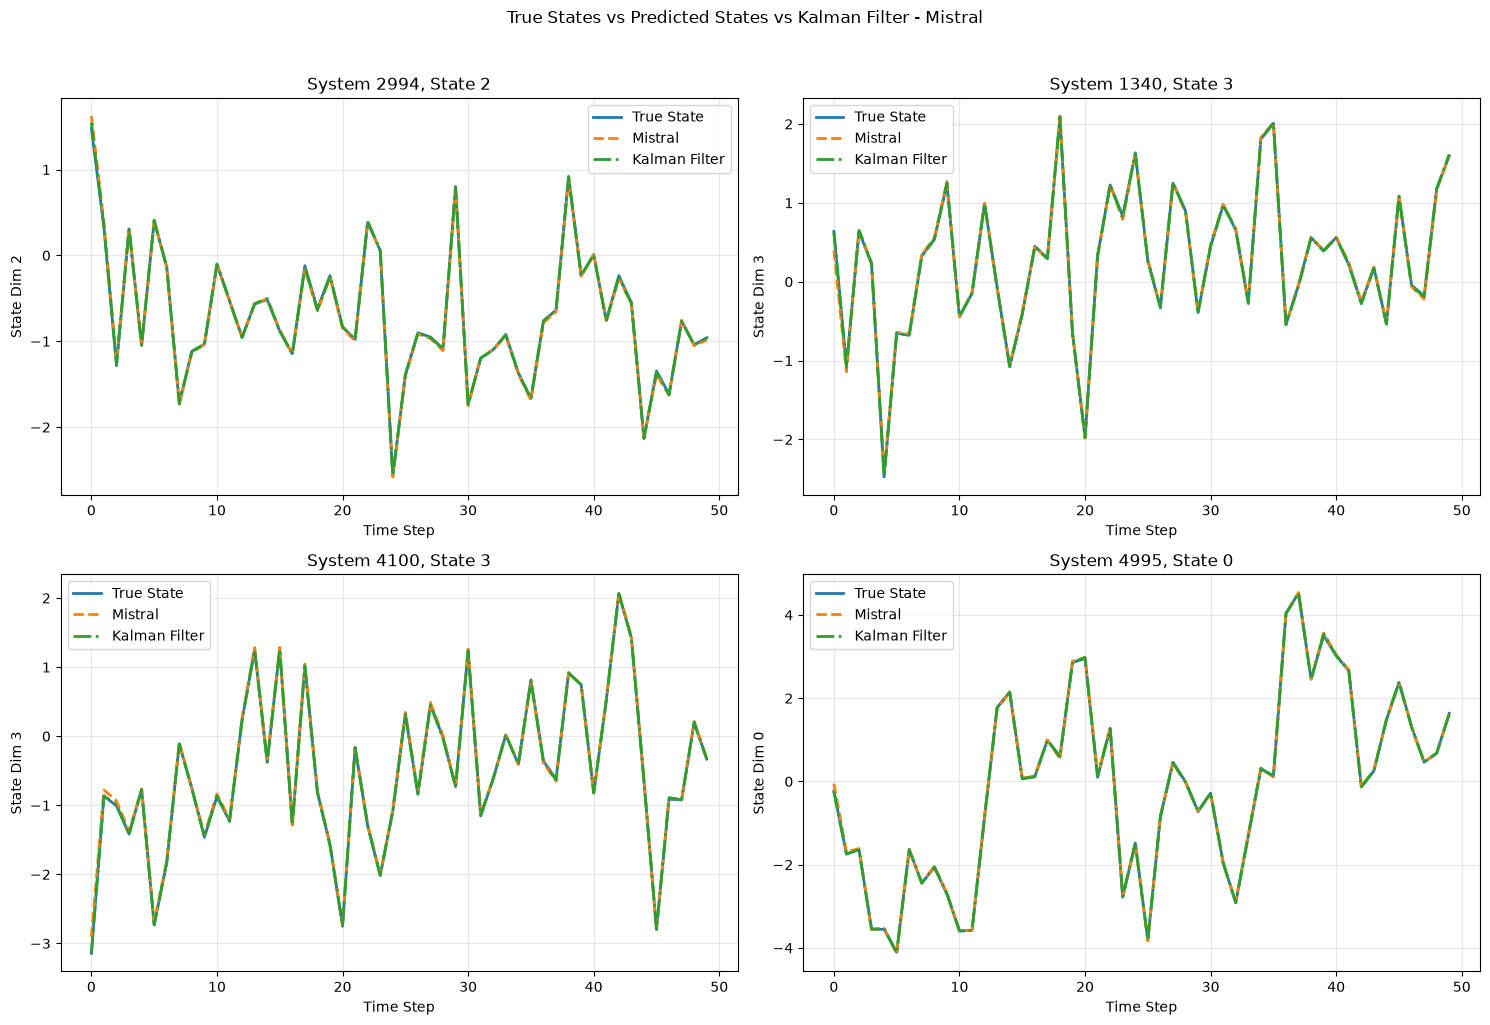

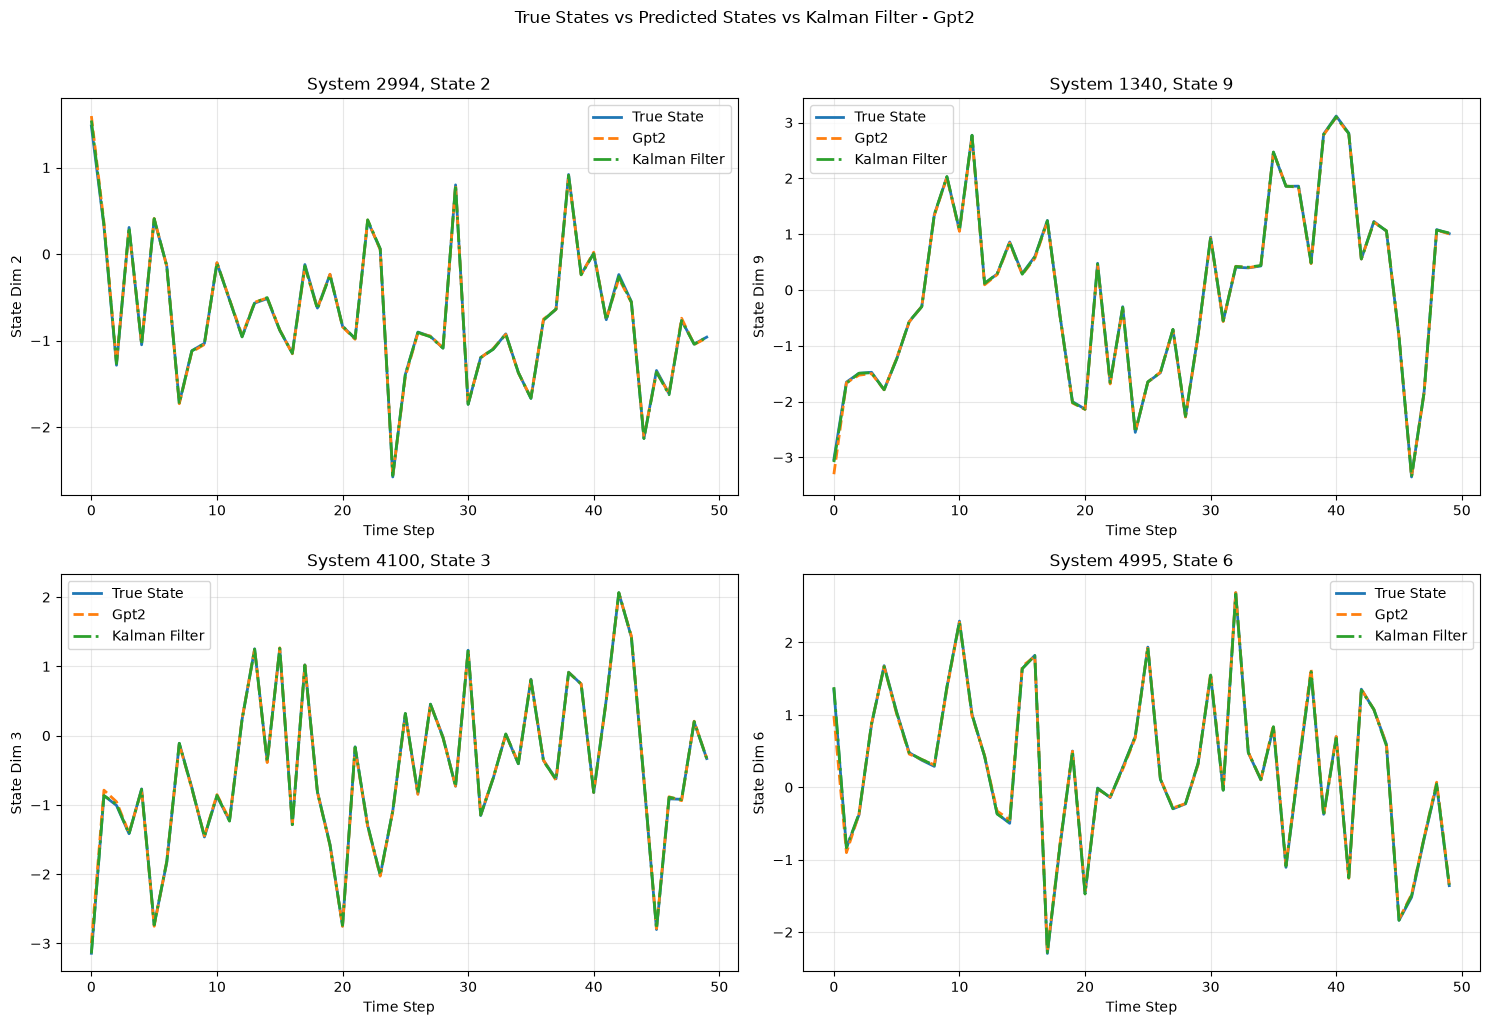

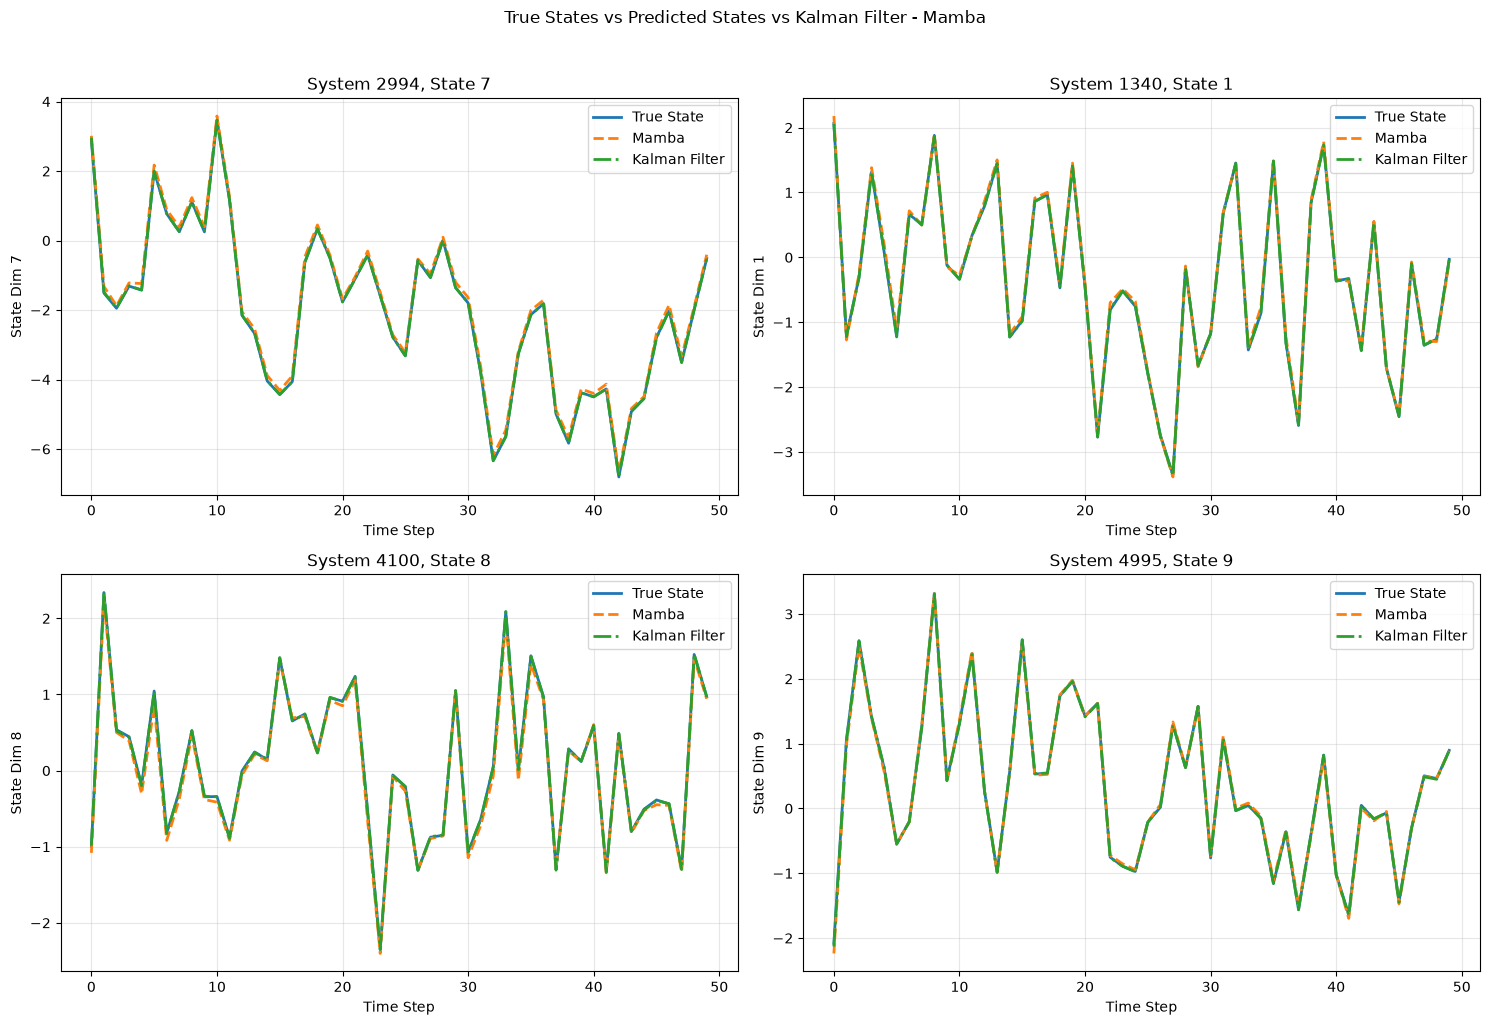

In [30]:
# 8. Example: Generate and Test Multiple Trajectories
num_trajs = CONFIG['num_test']
print(f'Generating {num_trajs} test trajectories for visualization...')
test_trajs = [
    generate_trajectory(
        nx=CONFIG['nx'],
        ny=CONFIG['ny'],
        traj_len=CONFIG['traj_len'],
        sigma_w=CONFIG['sigma_w_test'],
        sigma_v=CONFIG['sigma_v_test'],
        input_lower=CONFIG['input_lower_test'],
        input_upper=CONFIG['input_upper_test'],
        eig_low=CONFIG['eig_low_test'],
        eig_high=CONFIG['eig_high_test'],
        A = A,
        B = B,
        C = C
    )
    for _ in tqdm(range(num_trajs))
]

# Randomly sample 4 trajectory/state combinations for the trajectory plot
sampled_indices = rng.choice(len(test_trajs), size=4, replace=False)

# Store data for trajectory plot - one plot per selected model
plot_data_by_model = {model_name: [] for model_name in trained_models.keys()}

for idx, traj_idx in enumerate(sampled_indices):
    test_traj = test_trajs[traj_idx]
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get predictions for each trained model
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()

        # Get Kalman filter predictions
        kf_states = apply_kalman_filter_from_traj(test_traj)
        kf_preds = kf_states[1:]

        # Randomly select a state dimension to plot
        nx = CONFIG['nx']
        state_dim = rng.integers(0, nx)

        # Store data for trajectory plot
        plot_data_by_model[model_name].append({
            'states_true': states_true[1:, state_dim],
            f'{model_name}_preds': preds[:, state_dim],
            'kf_preds': kf_preds[:, state_dim],
            'state_dim': state_dim,
            'traj_idx': traj_idx,
            'model_name': model_name
        })

# Create trajectory comparison plots for each selected model
for model_name in trained_models.keys():
    plot_data = plot_data_by_model[model_name]
    plt.figure(figsize=(15, 10))
    model_display_name = model_name.capitalize()
    for idx, data in enumerate(plot_data):
        plt.subplot(2, 2, idx+1)
        plt.plot(data['states_true'], label='True State', linewidth=2)
        plt.plot(data[f'{model_name}_preds'], '--', label=model_display_name, linewidth=2)
        plt.plot(data['kf_preds'], '-.', label='Kalman Filter', linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel(f'State Dim {data["state_dim"]}')
        plt.title(f'System {data["traj_idx"]}, State {data["state_dim"]}')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.suptitle(f'True States vs Predicted States vs Kalman Filter - {model_display_name}', y=1.02)
    plt.tight_layout()
    plt.show()

Computing per-timestep summed L2 norm across all 5000 trajectories...


100%|██████████| 5000/5000 [01:12<00:00, 68.59it/s] 



Average Summed L2 Error across ALL 5000 trajectories:
Mistral: 3.944
GPT2: 3.429
Mamba: 10.873
Kalman Filter: 1.538


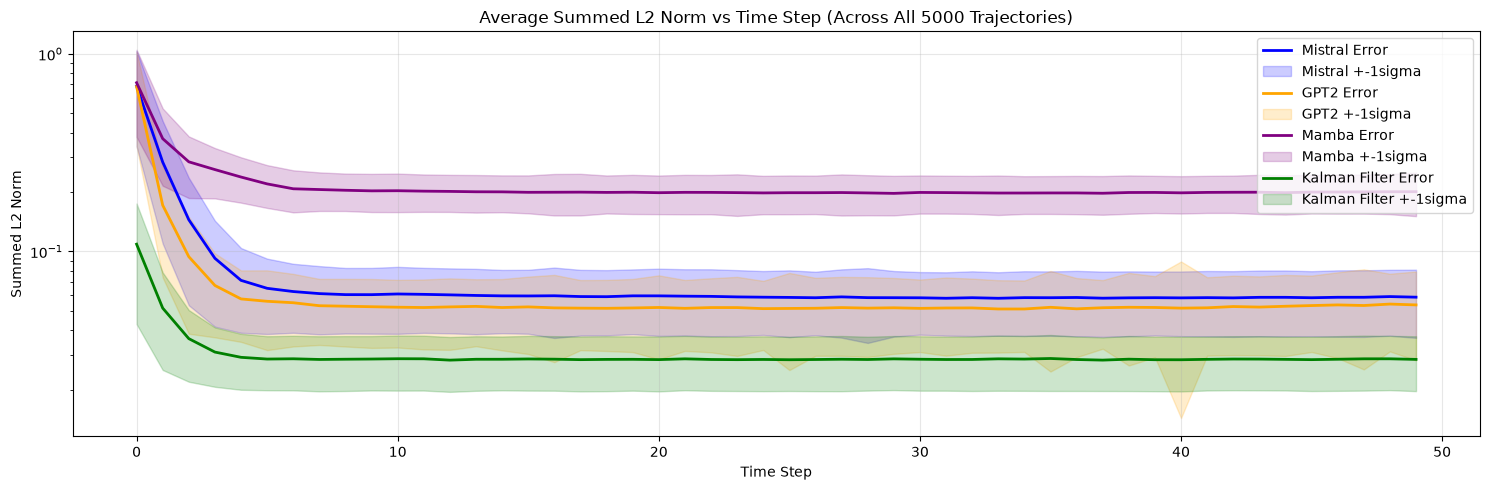

In [31]:
# Compute per-timestep summed L2 norm across ALL trajectories for each selected model
print(f'Computing per-timestep summed L2 norm across all {num_trajs} trajectories...')

# Initialize error storage for each model
all_per_timestep_l2_norms = {model_name: [] for model_name in trained_models.keys()}
all_kf_per_timestep_l2_norms = []

for test_traj in tqdm(test_trajs):
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get predictions for each trained model
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()
        actual_pred_len = preds.shape[0]
        actual_state_len = min(actual_pred_len, states_true[:-1].shape[0])

        # Compute per-timestep L2 norm
        per_timestep_err = np.linalg.norm((states_true[1:][:actual_state_len] - preds[:actual_state_len]), axis=-1)
        all_per_timestep_l2_norms[model_name].append(per_timestep_err)

    # Get Kalman filter predictions
    kf_states = apply_kalman_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]
    kf_pred_len = min(kf_preds.shape[0], states_true[:-1].shape[0])
    kf_per_timestep_err = np.linalg.norm((states_true[1:][:kf_pred_len] - kf_preds[:kf_pred_len]), axis=-1)
    all_kf_per_timestep_l2_norms.append(kf_per_timestep_err)

    # Compute average and std per-timestep error for each model
model_avg_errors = {}
model_std_errors = {}

for model_name in trained_models.keys():
    min_length = min(len(err_curve) for err_curve in all_per_timestep_l2_norms[model_name])
    trimmed_errs = [err_curve[:min_length] for err_curve in all_per_timestep_l2_norms[model_name]]
    model_avg_errors[model_name] = np.mean(trimmed_errs, axis=0)
    model_std_errors[model_name] = np.std(trimmed_errs, axis=0)

# Compute average and std per-timestep error for Kalman filter
kf_min_length = min(len(err_curve) for err_curve in all_kf_per_timestep_l2_norms)
trimmed_kf_errs = [err_curve[:kf_min_length] for err_curve in all_kf_per_timestep_l2_norms]
avg_kf_per_timestep_err = np.mean(trimmed_kf_errs, axis=0)
std_kf_per_timestep_err = np.std(trimmed_kf_errs, axis=0)

# Compute overall average error across all trajectories
model_traj_errors = {}
for model_name in trained_models.keys():
    traj_errs_sum = np.array([err_curve.sum() for err_curve in all_per_timestep_l2_norms[model_name]])
    model_traj_errors[model_name] = traj_errs_sum.mean()

kf_traj_errs_sum = np.array([err_curve.sum() for err_curve in all_kf_per_timestep_l2_norms])
avg_kf_err_all = kf_traj_errs_sum.mean()

# Create Figure 2: Error vs time step plot
plt.figure(figsize=(15, 5))

# Define colors for different models
model_colors = {'mistral': 'blue', 'gpt2': 'orange', 'mamba': 'purple'}
model_names_display = {'mistral': 'Mistral', 'gpt2': 'GPT2', 'mamba': 'Mamba'}

# Plot each selected model
for model_name in trained_models.keys():
    color = model_colors.get(model_name, 'gray')
    display_name = model_names_display.get(model_name, model_name)
    min_len = min(len(err_curve) for err_curve in all_per_timestep_l2_norms[model_name])

    plt.semilogy(model_avg_errors[model_name], label=f'{display_name} Error', linewidth=2, color=color)
    plt.fill_between(
        range(min_len),
        model_avg_errors[model_name] - model_std_errors[model_name],
        model_avg_errors[model_name] + model_std_errors[model_name],
        color=color,
        alpha=0.2,
        label=f'{display_name} +-1sigma'
    )

# Plot Kalman filter
plt.semilogy(avg_kf_per_timestep_err, label='Kalman Filter Error', linewidth=2, color='green')
plt.fill_between(
    range(kf_min_length),
    avg_kf_per_timestep_err - std_kf_per_timestep_err,
    avg_kf_per_timestep_err + std_kf_per_timestep_err,
    color='green',
    alpha=0.2,
    label='Kalman Filter +-1sigma'
)
plt.xlabel('Time Step')
plt.ylabel('Summed L2 Norm')
plt.title(f'Average Summed L2 Norm vs Time Step (Across All {num_trajs} Trajectories)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Print overall average errors
print(f'\nAverage Summed L2 Error across ALL {num_trajs} trajectories:')
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    print(f'{display_name}: {model_traj_errors[model_name]:.3f}')
print(f'Kalman Filter: {avg_kf_err_all:.3f}')


Finding best and worst state-trajectory pairs across 5000 trajectories...


100%|██████████| 5000/5000 [01:15<00:00, 66.31it/s] 



Mistral - Best 2 pairs:
  Traj 3382, State 8, MSE = 0.0000
  Traj 2903, State 8, MSE = 0.0000
Mistral - Worst 2 pairs:
  Traj 4516, State 4, MSE = 0.0691
  Traj 2540, State 4, MSE = 0.0582

GPT2 - Best 2 pairs:
  Traj 2174, State 8, MSE = 0.0000
  Traj 4519, State 8, MSE = 0.0000
GPT2 - Worst 2 pairs:
  Traj 4516, State 4, MSE = 0.0562
  Traj 4317, State 6, MSE = 0.0557

Mamba - Best 2 pairs:
  Traj 4380, State 3, MSE = 0.0006
  Traj 2299, State 3, MSE = 0.0006
Mamba - Worst 2 pairs:
  Traj 4516, State 4, MSE = 0.0862
  Traj 3991, State 4, MSE = 0.0663


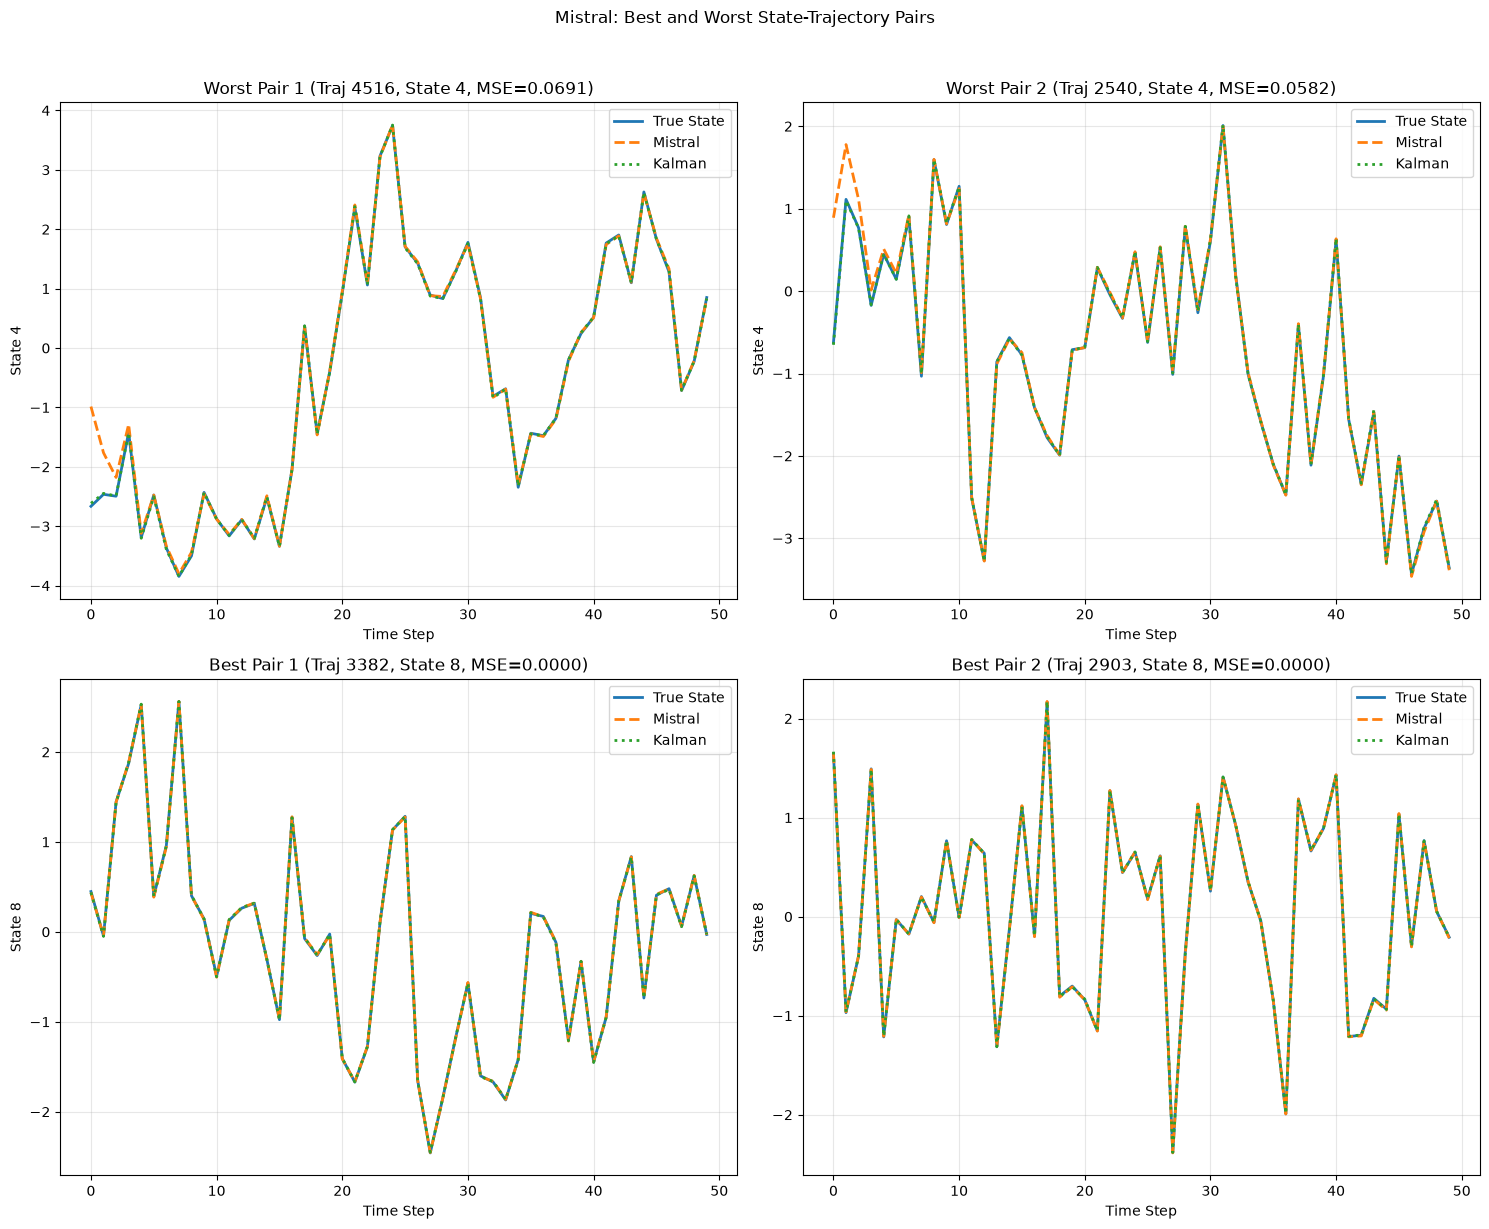

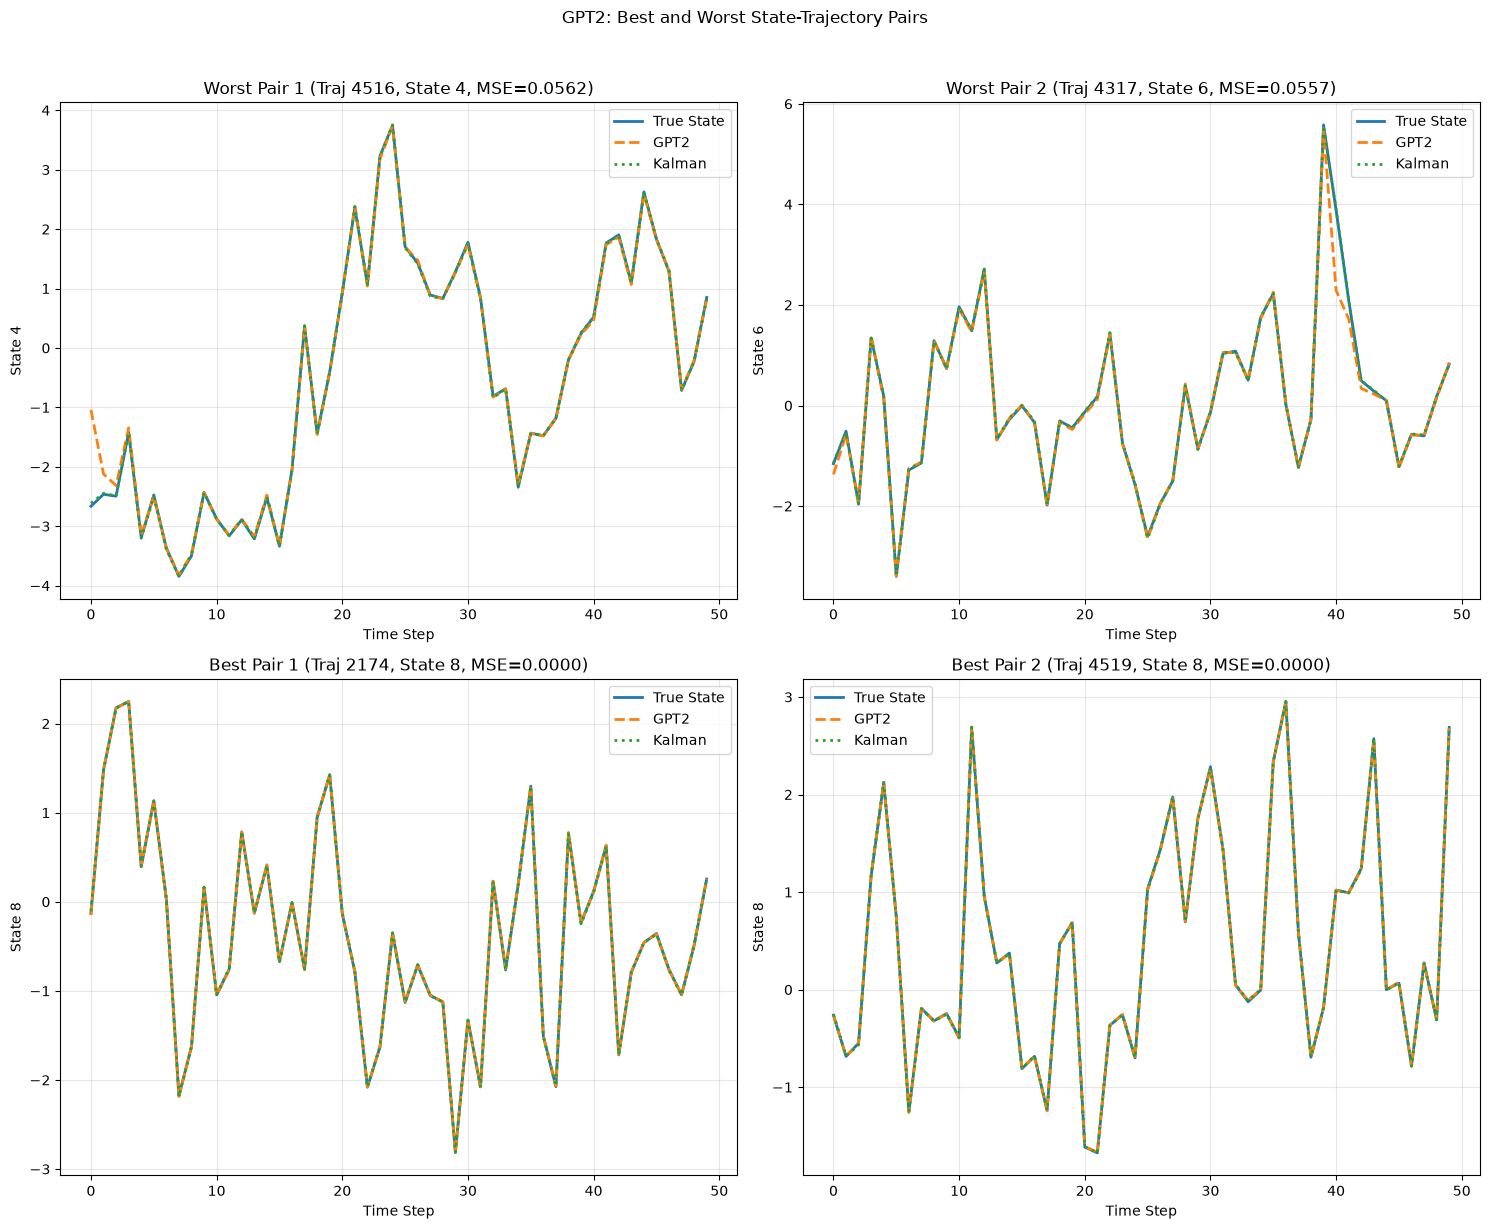

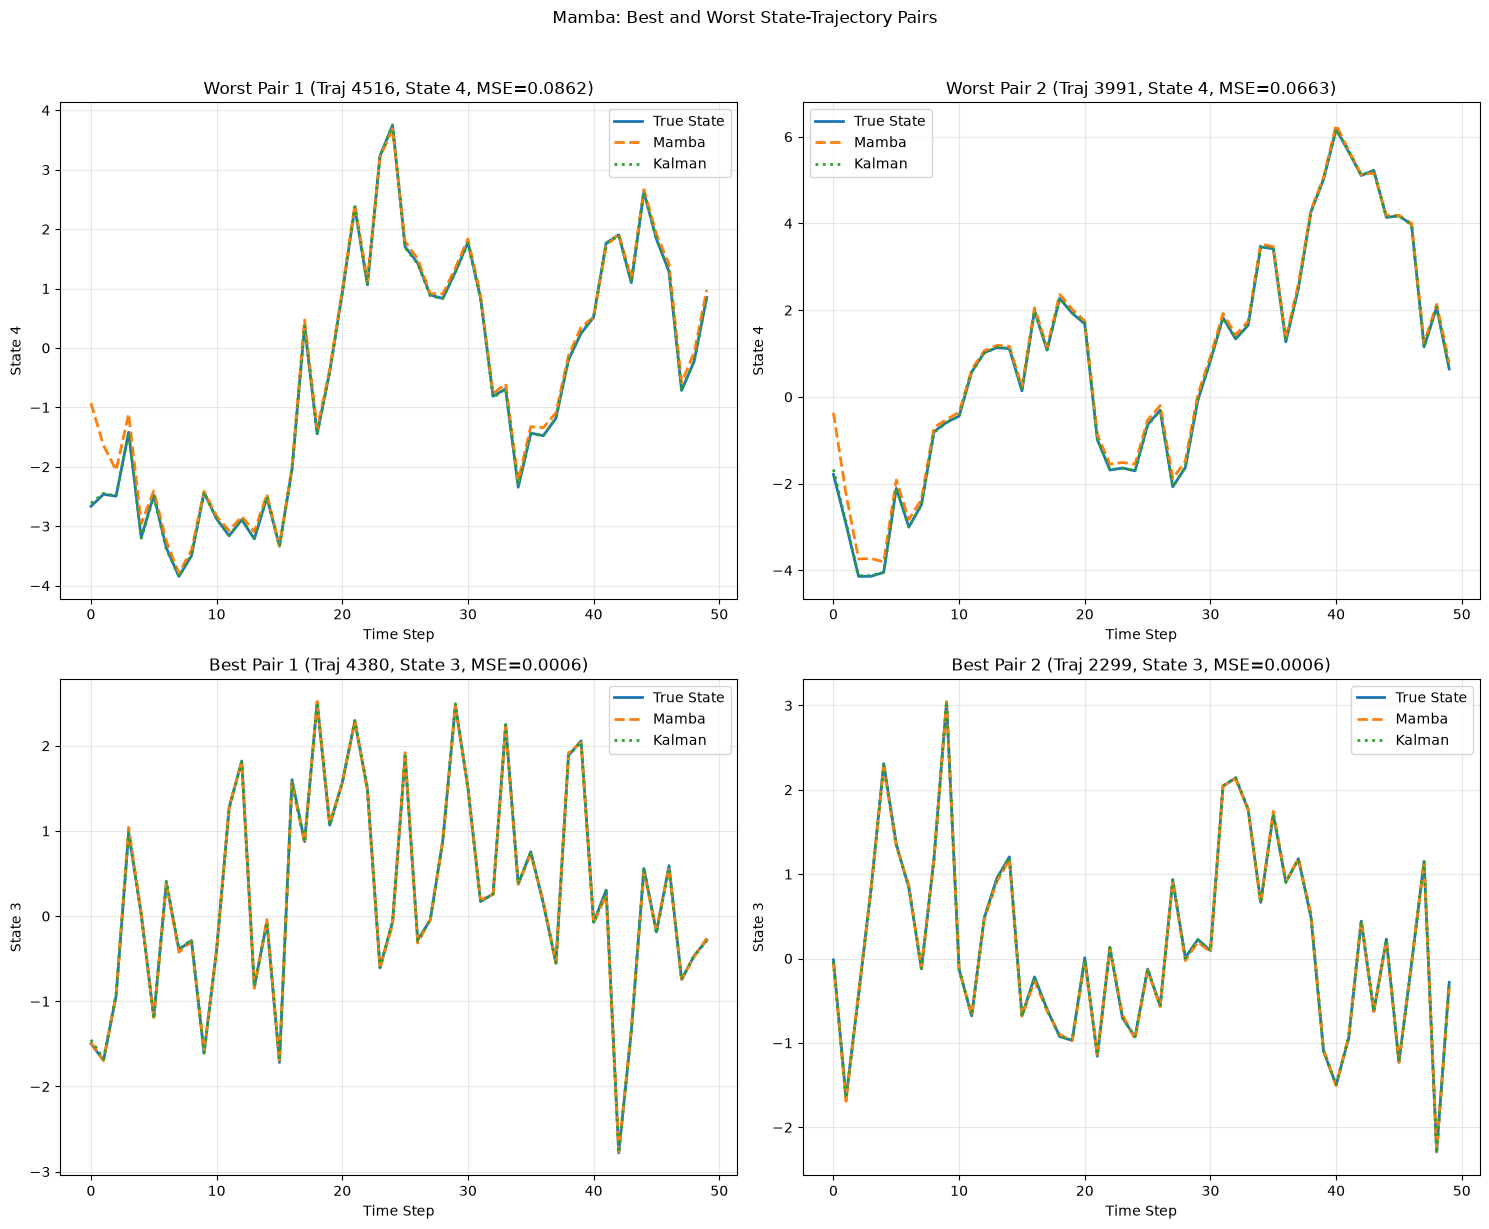

In [32]:
# Find 2 best and 2 worst-performing state-trajectory pairs across ALL test trajectories for each selected model
print(f'Finding best and worst state-trajectory pairs across {num_trajs} trajectories...')

# Initialize storage for best and worst pairs for all methods
model_best_pairs = {model_name: [] for model_name in trained_models.keys()}
model_worst_pairs = {model_name: [] for model_name in trained_models.keys()}

for traj_idx, test_traj in enumerate(tqdm(test_trajs)):
    states_true = test_traj['states']
    obs = test_traj['obs']
    inputs = test_traj['inputs']

    # Prepare input for models
    xs_for_model = np.concatenate([obs[1:], inputs], axis=-1)
    xs_tensor = torch.from_numpy(xs_for_model).float().unsqueeze(0).to(device)

    # Get Kalman filter predictions
    kf_states = apply_kalman_filter_from_traj(test_traj)
    kf_preds = kf_states[1:]

    # Get predictions for each model and find best/worst pairs
    for model_name, model in trained_models.items():
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            preds_tensor = model(xs_tensor)
        preds = preds_tensor.squeeze(0).cpu().numpy()

        actual_state_len = min(preds.shape[0], states_true[:-1].shape[0], kf_preds.shape[0])

        for state_dim in range(CONFIG['nx']):
            # Compute MSE for this pair
            pair_mse = np.mean((states_true[1:][:actual_state_len, state_dim] - preds[:actual_state_len, state_dim]) ** 2)

            pair_data = (pair_mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_state_len)

            # Add to best pairs (keep only top 2 lowest MSE)
            model_best_pairs[model_name].append(pair_data)
            model_best_pairs[model_name].sort(key=lambda x: x[0])  # Sort by MSE ascending
            if len(model_best_pairs[model_name]) > 2:
                model_best_pairs[model_name].pop()  # Remove worst of the best

            # Add to worst pairs (keep only top 2 highest MSE)
            model_worst_pairs[model_name].append(pair_data)
            model_worst_pairs[model_name].sort(key=lambda x: x[0], reverse=True)  # Sort by MSE descending
            if len(model_worst_pairs[model_name]) > 2:
                model_worst_pairs[model_name].pop()  # Remove best of the worst

# Print results for each model
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    print(f'\n{display_name} - Best 2 pairs:')
    for mse, traj_idx, state_dim, _, _, _, _ in model_best_pairs[model_name]:
        print(f'  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}')
    print(f'{display_name} - Worst 2 pairs:')
    for mse, traj_idx, state_dim, _, _, _, _ in model_worst_pairs[model_name]:
        print(f'  Traj {traj_idx}, State {state_dim}, MSE = {mse:.4f}')

# Create plots for each model
for model_name in trained_models.keys():
    display_name = model_names_display.get(model_name, model_name)
    all_pairs = model_worst_pairs[model_name] + model_best_pairs[model_name]
    titles = ['Worst Pair 1', 'Worst Pair 2', 'Best Pair 1', 'Best Pair 2']

    plt.figure(figsize=(15, 12))
    for idx, (mse, traj_idx, state_dim, states_true, preds, kf_preds, actual_len) in enumerate(all_pairs):
        plt.subplot(2, 2, idx + 1)
        plt.plot(states_true[1:, state_dim], label='True State', linewidth=2)
        plt.plot(preds[:actual_len, state_dim], '--', label=display_name, linewidth=2)
        plt.plot(kf_preds[:actual_len, state_dim], ':', label='Kalman', linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel(f'State {state_dim}')
        plt.title(f'{titles[idx]} (Traj {traj_idx}, State {state_dim}, MSE={mse:.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.suptitle(f'{display_name}: Best and Worst State-Trajectory Pairs', y=1.02)
    plt.tight_layout()
    plt.show()

In [35]:
# 9. Save and Load Model (Optional)

def save_model(model, model_name, path=None, config=None):
    """Save the trained model."""
    if path is None:
        path = f'{model_name}_sequence_model_filter_normal_{int(CONFIG['input_lower_train'])}_0{int(CONFIG['input_upper_train']*10)}.pth'
    if config is None:
        config = CONFIG
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'model_type': model.__class__.__name__,
        'model_name': model_name
    }, path)
    print(f'Model saved to {path}')

def load_model(path, model_name=None, config=None):
    """Load a saved model."""
    # Handle PyTorch 2.6+ weights_only default
    import sys
    if sys.version_info >= (3, 8):  # PyTorch 2.6+ compatibility
        import torch.serialization
        torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    if config is None:
        config = checkpoint.get('config', CONFIG)
    if model_name is None:
        model_name = checkpoint.get('model_name', 'mistral')

    model_type = checkpoint.get('model_type', 'Mistral7BFilter')
    input_dim = config.get('ny', 5) + config.get('nx', 10)
    output_dim = config.get('nx', 10)

    if model_type == 'Mistral7BFilter':
        model = Mistral7BFilter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            n_embd=config.get('n_embd', 128),
            n_layer=config.get('n_layer', 6),
            n_head=config.get('n_head', 4),
            dropout=config.get('gpt2_dropout', 0.15),
            learning_rate=config.get('gpt2_learning_rate', 1e-4),
            weight_decay=config.get('gpt2_weight_decay', 1e-4),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    elif model_type == 'GPT2Filter':
        model = GPT2Filter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            n_embd=config.get('gpt2_n_embd', 256),
            n_layer=config.get('gpt2_n_layer', 12),
            n_head=config.get('gpt2_n_head', 8),
            dropout=config.get('dropout', 0.1),
            learning_rate=config.get('gpt2_learning_rate', 3e-4),
            weight_decay=config.get('gpt2_weight_decay', 1e-2),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    elif model_type == 'MambaFilter':
        model = MambaFilter(
            input_dim=input_dim,
            output_dim=output_dim,
            n_positions=config.get('n_positions', 50),
            d_model=config.get('d_model', 256),
            n_layers=config.get('n_layers', 4),
            d_state=config.get('d_state', 16),
            d_conv=config.get('d_conv', 4),
            expand=config.get('expand', 2),
            learning_rate=config.get('learning_rate', 1e-4),
            weight_decay=config.get('weight_decay', 1e-4),
            gradient_clip=config.get('gradient_clip', 1.0)
        )
    else:
        raise ValueError(f'Unknown model type: {model_type}')

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f'Model loaded from {path}')
    return model, config, model_name

# # Save all trained models
# for model_name, model in trained_models.items():
#     save_model(model, model_name)
# print(f'All {len(trained_models)} models saved successfully!')

# Example: Load all saved models back
# Uncomment the following to load all saved models:
loaded_models = {}
for model_name in models.keys():
    try:
        loaded_model, loaded_config, loaded_model_name = load_model(f'{model_name}_sequence_model_filter_normal_{int(CONFIG['input_lower_train'])}_0{int(CONFIG['input_upper_train']*10)}.pth')
        loaded_models[model_name] = loaded_model
        print(f'Loaded {model_name} model successfully')
    except FileNotFoundError:
        print(f'No saved model found for {model_name}')
    except Exception as e:
        print(f'Error loading {model_name} model: {e}')
trained_models = loaded_models
print(f'Loaded {len(loaded_models)} models successfully')


Model loaded from mistral_sequence_model_filter_normal_0_01.pth
Loaded mistral model successfully
Model loaded from gpt2_sequence_model_filter_normal_0_01.pth
Loaded gpt2 model successfully
Model loaded from mamba_sequence_model_filter_normal_0_01.pth
Loaded mamba model successfully
Loaded 3 models successfully
